<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/kikim6114/nlp2026/blob/main/09.transformer_2.scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

In [ ]:
# Colab이나 Kaggle을 사용하는 경우가 아니면, 이 cell을 모두 주석화하여 skip할 것.
import os

repository_name = 'nlp2026'
repository_url = f'https://github.com/kikim6114/{repository_name}.git'

# 항상 루트 경로(/content/)로 이동 후 확인
%cd /content/

if not os.path.exists(repository_name):
    !git clone {repository_url}
    print(f"{repository_name} 클론 완료")
else:
    print(f"{repository_name} 폴더가 이미 존재합니다. 클론을 건너뜁니다.")
%cd nlp2026

/content
nlp2026 폴더가 이미 존재합니다. 클론을 건너뜁니다.
/content/nlp2026


# Step-by-step Transformer 구축

In [ ]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import sentencepiece as spm
import gdown
# import pandas as pd
# import sys

## 1. 샘플 입력(Batch) 준비

#### 사용할 입력 데이터 준비 및 `vocab` 로딩

In [ ]:
# !pip install --upgrade gdown

In [ ]:
dataset_folder = '1h58VFFL0ACe_jNQzTr-LeCYl_wS6D5w6'
dataset_url = f'https://drive.google.com/drive/folders/{dataset_folder}'

gdown.download_folder(dataset_url, quiet=False, use_cookies=False)

Retrieving folder contents


Retrieving folder 1XsDsXhCxUHk9xW1ftJbreRlkVJF20cBd kowiki
Processing file 1jFxmUDVJgKXPJRG73Qp-qd-cp_Hej7h5 kowiki.model
Processing file 1BLuq4mwvvydg_p2sEq-dEOp9QH2LWqdJ kowiki.txt
Processing file 1UTxElqqvVSsFpLz6exLytt1DmrKXj2jI kowiki.vocab


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1jFxmUDVJgKXPJRG73Qp-qd-cp_Hej7h5
To: /content/nlp2026/nlp2026-data/kowiki/kowiki.model
100%|██████████| 351k/351k [00:00<00:00, 97.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1BLuq4mwvvydg_p2sEq-dEOp9QH2LWqdJ
From (redirected): https://drive.google.com/uc?id=1BLuq4mwvvydg_p2sEq-dEOp9QH2LWqdJ&confirm=t&uuid=9fa40081-6cef-4f07-8cbb-28067b118c59
To: /content/nlp2026/nlp2026-data/kowiki/kowiki.txt
100%|██████████| 971M/971M [00:13<00:00, 72.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1UTxElqqvVSsFpLz6exLytt1DmrKXj2jI
To: /content/nlp2026/nlp2026-data/kowiki/kowiki.vocab
100%|██████████| 104k/104k [00:00<00:00, 43.9MB/s]
Download completed


['/content/nlp2026/nlp2026-data/kowiki/kowiki.model',
 '/content/nlp2026/nlp2026-data/kowiki/kowiki.txt',
 '/content/nlp2026/nlp2026-data/kowiki/kowiki.vocab']

In [ ]:
!ls -l ./nlp2026-data/kowiki

total 948808
-rw-r--r-- 1 root root    350876 May  7 04:07 kowiki.model
-rw-r--r-- 1 root root 971113679 May  6 14:32 kowiki.txt
-rw-r--r-- 1 root root    104019 May  7 04:07 kowiki.vocab


In [ ]:
vocab_file = "./nlp2026-data/kowiki/kowiki.model"   #  Local: "./kowiki/kowiki.model"
vocab = spm.SentencePieceProcessor()
vocab.load(vocab_file)
len(vocab)

8007

In [ ]:
lines = [
    "자연어처리에 관심이 많지만 좀 어렵다고 느껴집니다.",
    "너무 발전 속도가 빨라서 따라가기 벅차요.",
    "어떻게 하면 자연어처리 테크닉에 능숙할 수 있을까요?"
    ]

# text를 tensor로 변환
inputs = []
for line in lines:
    pieces = vocab.encode_as_pieces(line)
    ids = vocab.encode_as_ids(line)
    inputs.append(torch.tensor(ids))
    print(line)
    print(pieces)
    print(ids)

자연어처리에 관심이 많지만 좀 어렵다고 느껴집니다.
['▁자연', '어', '처', '리에', '▁관심', '이', '▁많', '지만', '▁좀', '▁어', '렵', '다고', '▁느', '껴', '집', '니다', '.']
[1145, 3754, 3969, 559, 3638, 3717, 210, 99, 3642, 137, 4465, 658, 1218, 5054, 3999, 1356, 3719]
너무 발전 속도가 빨라서 따라가기 벅차요.
['▁너무', '▁발전', '▁속', '도가', '▁빨', '라', '서', '▁따라', '가', '기', '▁', '벅', '차', '요', '.']
[2796, 1046, 293, 893, 2903, 3753, 3732, 264, 3728, 3735, 3716, 5160, 3872, 3886, 3719]
어떻게 하면 자연어처리 테크닉에 능숙할 수 있을까요?
['▁어떻게', '▁하', '면', '▁자연', '어', '처', '리', '▁테', '크', '닉', '에', '▁능', '숙', '할', '▁수', '▁있을', '까', '요', '?']
[3372, 29, 3833, 1145, 3754, 3969, 3738, 519, 3863, 4452, 3720, 1049, 4279, 3882, 18, 1413, 3925, 3886, 4406]


In [ ]:
inputs

[tensor([1145, 3754, 3969,  559, 3638, 3717,  210,   99, 3642,  137, 4465,  658,
         1218, 5054, 3999, 1356, 3719]),
 tensor([2796, 1046,  293,  893, 2903, 3753, 3732,  264, 3728, 3735, 3716, 5160,
         3872, 3886, 3719]),
 tensor([3372,   29, 3833, 1145, 3754, 3969, 3738,  519, 3863, 4452, 3720, 1049,
         4279, 3882,   18, 1413, 3925, 3886, 4406])]

## 2. Embedding

### Padding
- `max_seq_length` 보다 길이가 짧은 입력 시퀀스의 뒷부분을 `padding-value`로 채워준다.
- batch_size = 3
- max_seq_length = 20
- pad_value = 0
- max_seq_length 보다 긴 문장은 이전 단계에서 truncate시킨 것으로 가정한다.
- 입력의 첫번째 시퀀스를 max_seq_length가 되도록 1D padding 시킨다음 전체를 padding

<span style="color:orange">나중에 코드를 클래스화하는 단계에서는 Attention 처리 단계에서 Padding까지 처리할 것이다.(checkpoint)</span>

In [ ]:
inputs[0]

tensor([1145, 3754, 3969,  559, 3638, 3717,  210,   99, 3642,  137, 4465,  658,
        1218, 5054, 3999, 1356, 3719])

In [ ]:
max_seq_length = 20
x = torch.zeros(max_seq_length, dtype=torch.int64)
x[:len(inputs[0])] = inputs[0]  # 최대길이 zero 시퀀스의 앞부분을 input[0]으로 채움.
inputs[0] = x  # input[0]의 zero-padding 완료
inputs = torch.nn.utils.rnn.pad_sequence(inputs, batch_first=True, padding_value=0)  # [참고] tutorscode-1
print(inputs.size())
print(inputs)

torch.Size([3, 20])
tensor([[1145, 3754, 3969,  559, 3638, 3717,  210,   99, 3642,  137, 4465,  658,
         1218, 5054, 3999, 1356, 3719,    0,    0,    0],
        [2796, 1046,  293,  893, 2903, 3753, 3732,  264, 3728, 3735, 3716, 5160,
         3872, 3886, 3719,    0,    0,    0,    0,    0],
        [3372,   29, 3833, 1145, 3754, 3969, 3738,  519, 3863, 4452, 3720, 1049,
         4279, 3882,   18, 1413, 3925, 3886, 4406,    0]])


### Input Embedding

In [ ]:
vocab_size = len(vocab) # 어휘(토큰) 수 - 단어 수가 아님
d_model = 128 # model 차원 (embedding 차원, hidden layer 크기)
nn_emb = nn.Embedding(vocab_size, d_model)
input_embs = nn_emb(inputs) # input embedding
print(f"vocab size = {len(vocab)}")
print(input_embs.size())

vocab size = 8007
torch.Size([3, 20, 128])


### Positional Encoding

<img src="https://github.com/kikim6114/nlp2026/blob/main/images/positional_encoding_1.png?raw=1" width="300" style="margin-left: auto; margin-right: auto">
<br>
<img src="https://github.com/kikim6114/nlp2026/blob/main/images/positional_encoding_2.png?raw=1" width="300" style="margin-left: auto; margin-right: auto">

<p style="text-align: center;">Positional Encoding 함수</p>

In [ ]:
def pos_encoding_table(seq_length, d_model):
    # 1. position 행렬 생성: (seq_length, 1)
    position = np.arange(seq_length)[:, np.newaxis]

    # 2. i_model 인덱스 행렬 생성: (d_model,)
    #    2 * (i // 2) 처리를 통해 짝수/홀수 인덱스가 동일한 분모를 갖게 함
    i = np.arange(d_model)

    # 3. angle_rates 행렬 만들기: (seq_length, d_model) => broadcasting 기능 이용 (tutor)
    angle_rates = position / np.power(10000, (2 * (i // 2)) / d_model)   # [참고] tutorscode-2

    # 4. 슬라이싱을 사용하여 짝수 열에는 sin, 홀수 열에는 cos 적용
    angle_rates[:, 0::2] = np.sin(angle_rates[:, 0::2])
    angle_rates[:, 1::2] = np.cos(angle_rates[:, 1::2])

    return angle_rates

#### Positional Encoding Table

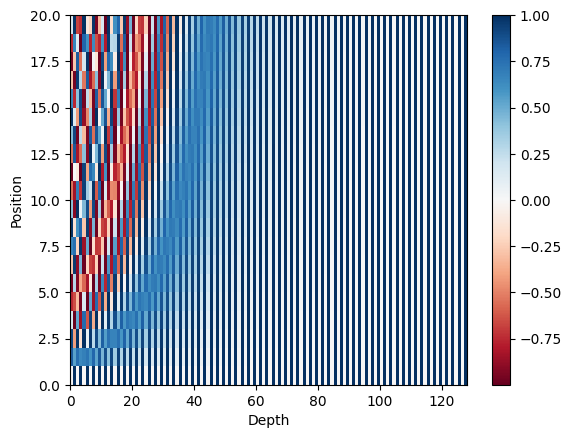

In [ ]:
pe = pos_encoding_table(seq_length=20, d_model=128)  # 64
plt.pcolormesh(pe, cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, d_model))
plt.ylabel('Position')
plt.colorbar()
plt.show()

In [ ]:
type(pe)

numpy.ndarray

#### Positional Embedding 절차
1. 위에서 얻은 position encoding값(pe)를 사용해 position emgedding을 생성.
2. 학습되는 값이 아니므로 `freeze option`을 `True`로 설정.
3. 입력인 `inputs`과 동일한 크기를 갖는 텐서 `positions`을 생성한다.
4. `inputs` 내부에서 padding처리된 요소들(값이 0인 요소)을 찾아서 mask를 만든다.
5. `positions`에 mask를 적용한다.
6. `positions`에 해당하는 embedding을 구한다

In [ ]:
from torch import nn
pe = torch.FloatTensor(pe)
nn_pos = nn.Embedding.from_pretrained(pe, freeze=True)  # 직접 만든 pe를 임베딩층의 가중치로 사용하겠다.

# 위치 인덱스 행렬 만들기
# inputs.shape = (3, 20): 0 ~ 19까지의 위치 인덱스로된 벡터를 만들고 batch크기(3) 만큼 복사하여 확장 => (3, 20)
# [참고] tutorscode-3
# +1 을 하는 이유: padding 값이 0 이므로, 위치 인덱스는 1 부터 시작하게 함.
positions = torch.arange(inputs.size(1), device=inputs.device, dtype=inputs.dtype).expand(inputs.size(0), inputs.size(1)).contiguous() + 1

pos_mask = inputs.eq(0)  # 0 으로 패딩된 것들로 mask 만듬
positions.masked_fill_(pos_mask, 0)  # 패딩된곳은 0, 실제 토큰이 있는 곳은 1, 2, ... 의 값을 갖게 됨
pos_embs = nn_pos(positions) # position embedding (batch_size, seq_length, d_model)

print(inputs)
print(positions)
print(pos_embs.size())

tensor([[1145, 3754, 3969,  559, 3638, 3717,  210,   99, 3642,  137, 4465,  658,
         1218, 5054, 3999, 1356, 3719,    0,    0,    0],
        [2796, 1046,  293,  893, 2903, 3753, 3732,  264, 3728, 3735, 3716, 5160,
         3872, 3886, 3719,    0,    0,    0,    0,    0],
        [3372,   29, 3833, 1145, 3754, 3969, 3738,  519, 3863, 4452, 3720, 1049,
         4279, 3882,   18, 1413, 3925, 3886, 4406,    0]])
tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,  0,
          0,  0],
        [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,  0,  0,  0,
          0,  0],
        [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
         19,  0]])
torch.Size([3, 20, 128])


In [ ]:
nn_pos

Embedding(20, 128)

### Positional Encoding된 입력

In [ ]:
input_sums = input_embs + pos_embs

## 3. Scaled Dot Product Attention

In [ ]:
input_sums.shape

torch.Size([3, 20, 128])

### Attention Mask

In [ ]:
Q = input_sums
K = input_sums
V = input_sums

attn_mask = inputs.eq(0).unsqueeze(1).expand(Q.size(0), Q.size(1), K.size(1))  # [참고] tutorscode-4: unsqueeze()
print(attn_mask.size())
print(attn_mask[0])

torch.Size([3, 20, 20])
tensor([[False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False,  True,  True,  True],
        [False, False,

`attn_mask` 계산 과정 설명:
1. 최초 `inputs`의 차원은 (batch_size, seq_length) = (3,20)이다.
2. `Q`, `K` 및 `V`의 차원은 (batch_size, seq_length, d_model) = (3, 20, 128)이다.
3. `attn_mask`의 크기는 (batch_size, seq_length, seq_length) = (3,20, 20) 이 되어야 한다.
4. inputs.eq(0) : padding된 0 이 있는 위치에서만 True이고 나머지는 False인 (3,20) 텐서.
5. inputs.eq(0).unsqueeze(1) : dim(또는 axis) 추가하여 (3,1,20) 텐서를 만들고
6. expand(Q.size(0), Q.size(1), K.size(1)) : 0-dim 자리는 3인데 Q.size(0)=3 이므로 그대로 두고, 1-dim은 1인데 Q.size(1)=20 이므로 복사 확장, 2-dim은 20인데 K.size(1)=20 이므로 그대로 둔다.
- <span style="color:IndianRed">**[주의]**</span> size가 1이 아닌 dim을 확장하려고 하면 오류.

### matmul(Q, K-transpose)
PyTorch tensor의 곱셈 연산 원리를 확실히 알고 있어야 한다.

#### 3rd-order 이상($k \times l \times m \times \cdots$)의 텐서 연산
- `numpy.dot(Q, K)`는 Q의 마지막 axis와 K의 마지막에서 두번째 axis끼리 곱한 결과를 반영
- `matmul(Q, K)` 또는 `Q @ K`는, Q의 마지막 두 axis 차원이 (..., m, p), K의 마지막 두 axis 차원이 (..., p, n)라고 하면, 이 사이에서만 곱하여 (..., n, m) 차원이 된다.<br>
  **(예)** (8 x 12 x 30 x 100) @ ((8 x 12 x 30 x 100) ⟹ (... 30 x 100) @ (... 30 x 100) <br>
⟹  차원이 맞지 않으므로 마지막 두 차원을 `transpose(-2, -1)` 한다 <br>
⟹  (8 x 12 x 30 x 100) @ ((8 x 12 x 100 x 30) ⟹ (... 30 x 100) @ (... 100 x 30)
⟹  (8 x 12 x 30 x 30)

In [ ]:
scores = torch.matmul(Q, K.transpose(-1, -2))
print(scores.size())
print(scores[0])

torch.Size([3, 20, 20])
tensor([[168.5888,  51.2134,  63.6549,  42.8491,  30.7937,  45.6040,  34.5838,
          46.6457,  24.8655,  37.3137,  35.9242,  20.9954,  25.0619,  75.3091,
          23.1680,  41.7566,  69.1286,  72.9876,  72.9876,  72.9876],
        [ 51.2134, 183.6195,  57.2849,  66.1590,  33.3200,  56.4817,  26.2516,
          41.2211,  44.4763,  39.9143,  15.6049,  59.0709,  37.8902,  39.2426,
          24.8884,  48.4126,  53.1970,  62.1844,  62.1844,  62.1844],
        [ 63.6549,  57.2849, 186.8764,  53.2990,  41.9547,  71.9663,  28.6606,
          60.9346,  13.4838,  43.1782,  22.1296,  48.2918,  28.0549,  68.0057,
          21.9104,  23.6338,  51.7538,  65.4890,  65.4890,  65.4890],
        [ 42.8491,  66.1590,  53.2990, 192.5363,  52.1110,  69.7026,  50.2911,
          48.7742,  26.4681,  47.7219,  42.0854,  58.9021,  45.5045,  65.4994,
          53.6596,  74.4163,  63.0990,  61.1387,  61.1387,  61.1387],
        [ 30.7937,  33.3200,  41.9547,  52.1110, 157.7093,  29.0

### Scaling

In [ ]:
d_k = 64
scores = scores.mul_(1/d_k**0.5)  # inplace operations
print(scores.size())
print(scores[0])

torch.Size([3, 20, 20])
tensor([[21.0736,  6.4017,  7.9569,  5.3561,  3.8492,  5.7005,  4.3230,  5.8307,
          3.1082,  4.6642,  4.4905,  2.6244,  3.1327,  9.4136,  2.8960,  5.2196,
          8.6411,  9.1235,  9.1235,  9.1235],
        [ 6.4017, 22.9524,  7.1606,  8.2699,  4.1650,  7.0602,  3.2814,  5.1526,
          5.5595,  4.9893,  1.9506,  7.3839,  4.7363,  4.9053,  3.1111,  6.0516,
          6.6496,  7.7730,  7.7730,  7.7730],
        [ 7.9569,  7.1606, 23.3596,  6.6624,  5.2443,  8.9958,  3.5826,  7.6168,
          1.6855,  5.3973,  2.7662,  6.0365,  3.5069,  8.5007,  2.7388,  2.9542,
          6.4692,  8.1861,  8.1861,  8.1861],
        [ 5.3561,  8.2699,  6.6624, 24.0670,  6.5139,  8.7128,  6.2864,  6.0968,
          3.3085,  5.9652,  5.2607,  7.3628,  5.6881,  8.1874,  6.7074,  9.3020,
          7.8874,  7.6423,  7.6423,  7.6423],
        [ 3.8492,  4.1650,  5.2443,  6.5139, 19.7137,  3.6363,  3.2036,  3.9925,
          4.9121,  4.7847,  4.1598,  0.4777,  2.8018,  3.3104, 

### Mask (Opt.)

In [ ]:
float("-inf") < -1e9

True

In [ ]:
scores.masked_fill_(attn_mask, float("-inf"))  # -1e9 보다 나을까?
print(scores.size())
print(scores[0])

torch.Size([3, 20, 20])
tensor([[21.0736,  6.4017,  7.9569,  5.3561,  3.8492,  5.7005,  4.3230,  5.8307,
          3.1082,  4.6642,  4.4905,  2.6244,  3.1327,  9.4136,  2.8960,  5.2196,
          8.6411,    -inf,    -inf,    -inf],
        [ 6.4017, 22.9524,  7.1606,  8.2699,  4.1650,  7.0602,  3.2814,  5.1526,
          5.5595,  4.9893,  1.9506,  7.3839,  4.7363,  4.9053,  3.1111,  6.0516,
          6.6496,    -inf,    -inf,    -inf],
        [ 7.9569,  7.1606, 23.3596,  6.6624,  5.2443,  8.9958,  3.5826,  7.6168,
          1.6855,  5.3973,  2.7662,  6.0365,  3.5069,  8.5007,  2.7388,  2.9542,
          6.4692,    -inf,    -inf,    -inf],
        [ 5.3561,  8.2699,  6.6624, 24.0670,  6.5139,  8.7128,  6.2864,  6.0968,
          3.3085,  5.9652,  5.2607,  7.3628,  5.6881,  8.1874,  6.7074,  9.3020,
          7.8874,    -inf,    -inf,    -inf],
        [ 3.8492,  4.1650,  5.2443,  6.5139, 19.7137,  3.6363,  3.2036,  3.9925,
          4.9121,  4.7847,  4.1598,  0.4777,  2.8018,  3.3104, 

### Softmax

In [ ]:
attn_prob = nn.Softmax(dim=-1)(scores)
print(attn_prob.size())
print(attn_prob[0])

torch.Size([3, 20, 20])
tensor([[9.9998e-01, 4.2467e-07, 2.0113e-06, 1.4928e-07, 3.3078e-08, 2.1064e-07,
         5.3123e-08, 2.3993e-07, 1.5766e-08, 7.4728e-08, 6.2814e-08, 9.7189e-09,
         1.6157e-08, 8.6324e-06, 1.2751e-08, 1.3022e-07, 3.9867e-06, 0.0000e+00,
         0.0000e+00, 0.0000e+00],
        [6.4877e-08, 1.0000e+00, 1.3858e-07, 4.2019e-07, 6.9298e-09, 1.2534e-07,
         2.8642e-09, 1.8606e-08, 2.7949e-08, 1.5802e-08, 7.5687e-10, 1.7324e-07,
         1.2269e-08, 1.4529e-08, 2.4154e-09, 4.5714e-08, 8.3134e-08, 0.0000e+00,
         0.0000e+00, 0.0000e+00],
        [2.0450e-07, 9.2234e-08, 1.0000e+00, 5.6041e-08, 1.3573e-08, 5.7795e-07,
         2.5761e-09, 1.4555e-07, 3.8642e-10, 1.5815e-08, 1.1387e-09, 2.9970e-08,
         2.3883e-09, 3.5228e-07, 1.1079e-09, 1.3743e-09, 4.6198e-08, 0.0000e+00,
         0.0000e+00, 0.0000e+00],
        [7.4810e-09, 1.3784e-07, 2.7622e-08, 1.0000e+00, 2.3810e-08, 2.1466e-07,
         1.8965e-08, 1.5690e-08, 9.6535e-10, 1.3756e-08, 6.7999e

- Mask로 float("-inf") 또는 -1e9 를 사용한 경우 모두 mask된 값들이 0이 됨

In [ ]:
V.shape

torch.Size([3, 20, 128])

### matmul(attn_prob, V)

In [ ]:
context = torch.matmul(attn_prob, V)  # (3, 20, 20) x (3, 20, 128)
print(context.size())

torch.Size([3, 20, 128])


### ScaledDotProductAttention Class 화
- 앞에서는 Q, K, V 가 rank=3 인 텐서인 경우의 코딩이었다.
- `ScaledDotProductAttention` class는 Multihead Attention을 고려하여 rank=4인 텐서를 다룬다.

In [ ]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k):
        super().__init__()
        self.scale = 1 / (d_k ** 0.5)  # d_k : head의 크기(차원), d_k = d_model // num_head

    def forward(self, Q, K, V, attn_mask):
        # Q, K, V : (batch_size, num_head, seq_length, d_k)
        # scores: (batch_size, num_head, seq_length, seq_length)
        scores = torch.matmul(Q, K.transpose(-1, -2)).mul_(self.scale)
        scores.masked_fill_(attn_mask, -1e9)
        attn_prob = nn.Softmax(dim=-1)(scores)  # (batch_size, num_head, seq_length, seq_length)
        context = torch.matmul(attn_prob, V)    # (batch_size, num_head, seq_length, d_k)
        return context, attn_prob

## 4. Multi-Head Attention

In [ ]:
Q = input_sums # (batch_size, num_head, seq_length, d_model)
K = input_sums
V = input_sums
attn_mask = inputs.eq(0).unsqueeze(1).expand(Q.size(0), Q.size(1), K.size(1))
batch_size = Q.size(0)
num_head = 2

### Multi Head Q, K, V 입력

In [ ]:
d_k = d_model // num_head
W_q = nn.Linear(d_model, num_head * d_k)  # = nn.Linear(d_model, d_model)
W_k = nn.Linear(d_model, num_head * d_k)
W_v = nn.Linear(d_model, num_head * d_k)

q_s = W_q(Q)  # (batch_size, seq_length, num_head * d_k)
q_s = q_s.view(batch_size, -1, num_head, d_k)  # (batch_size, seq_length, num_head, d_k)
q_s = q_s.transpose(1,2)  # (batch_size, num_head, seq_length, d_k)

In [ ]:
print(q_s.size())

torch.Size([3, 2, 20, 64])


#### 위의 과정을 간략히 표현하면

In [ ]:
q_s = W_q(Q).view(batch_size, -1, num_head, d_k).transpose(1,2)
k_s = W_k(K).view(batch_size, -1, num_head, d_k).transpose(1,2)
v_s = W_v(V).view(batch_size, -1, num_head, d_k).transpose(1,2)
print(q_s.size(), k_s.size(), v_s.size())

torch.Size([3, 2, 20, 64]) torch.Size([3, 2, 20, 64]) torch.Size([3, 2, 20, 64])


### Attention Mask도 Multi Head로 변경

In [ ]:
print(attn_mask.size())
attn_mask = attn_mask.unsqueeze(1).repeat(1, num_head, 1, 1)
print(attn_mask.size())

torch.Size([3, 20, 20])
torch.Size([3, 2, 20, 20])


### Attention

In [ ]:
scaled_dot_attn = ScaledDotProductAttention(d_k)
context, attn_prob = scaled_dot_attn(q_s, k_s, v_s, attn_mask)
print(context.size())
print(attn_prob.size())

torch.Size([3, 2, 20, 64])
torch.Size([3, 2, 20, 20])


### Concat

In [ ]:
# (batch_size, seq_length, num_head * d_k)
context = context.transpose(1, 2).contiguous().view(batch_size, -1, num_head * d_k)
print(context.size())

torch.Size([3, 20, 128])


### Linear

In [ ]:
linear = nn.Linear(num_head * d_k, d_model)
# (batch_size, seq_length, d_model)
output = linear(context)
print(output.size())

torch.Size([3, 20, 128])


### 앞의 코드들을 Class 화

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_head, d_k):
        super().__init__()
        self.d_model = d_model
        self.num_head = num_head
        self.d_k = d_k

        self.W_q = nn.Linear(d_model, num_head * d_k)
        self.W_k = nn.Linear(d_model, num_head * d_k)
        self.W_v = nn.Linear(d_model, num_head * d_k)
        self.scaled_dot_attn = ScaledDotProductAttention(d_k)
        self.linear = nn.Linear(num_head * d_k, d_model)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.size(0)
        q_s = self.W_q(Q).view(batch_size, -1, self.num_head, self.d_k).transpose(1,2)
        k_s = self.W_k(K).view(batch_size, -1, self.num_head, self.d_k).transpose(1,2)
        v_s = self.W_v(V).view(batch_size, -1, self.num_head, self.d_k).transpose(1,2)
        attn_mask = attn_mask.unsqueeze(1).repeat(1, self.num_head, 1, 1)
        context, attn_prob = self.scaled_dot_attn(q_s, k_s, v_s, attn_mask)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.num_head * self.d_k)
        output = self.linear(context)
        return output, attn_prob

## 5. Masked Multi-Head Attention
- attention mask 부분을 제외한 나머지는 Multi-Head Attention과 모두 동일함.

### Decoder attention mask

In [ ]:
def antipeep_future_mask(seq):
    antipeep_mask = torch.ones_like(seq).unsqueeze(-1).expand(seq.size(0), seq.size(1), seq.size(1))
    antipeep_mask = antipeep_mask.triu(diagonal=1) # upper triangular part of a matrix(2-D)
    return antipeep_mask # (batch_size, seq_length, seq_length)

In [ ]:
Q = input_sums
K = input_sums
V = input_sums

attn_pad_mask = inputs.eq(0).unsqueeze(1).expand(Q.size(0), Q.size(1), K.size(1))
attn_dec_mask = antipeep_future_mask(inputs)  # (batch_size, seq_length, seq_length)
attn_mask = torch.gt((attn_pad_mask + attn_dec_mask), 0)  # greater tha zero?

print(attn_pad_mask[1])
print(attn_dec_mask[1])
print(attn_mask[1])

batch_size = Q.size(0)
num_head = 2

tensor([[False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, Fa

In [ ]:
a = torch.ones(20, 20, dtype=torch.int)
a.masked_fill_(attn_mask[1], 0)
a

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1,

### Multi-Head Attention
- 나머지는 Encoder의 MultiHead Attention과 동일하므로 앞에서 선언한 MultiHeadAttention 클래스를 바로 호출

In [ ]:
attention = MultiHeadAttention(d_model, num_head, d_k)
output, attn_prob = attention(Q, K, V, attn_mask)
print(output.size(), attn_prob.size())

torch.Size([3, 20, 128]) torch.Size([3, 2, 20, 20])


## 6. FeeedForward
- 비선형성 추가
- $f_2 = W_2\mathrm {ReLU}(f_1 = xW_1 + b_1) + b_2$
- 최근부터, ReLU 보다는 GELU(Gaussian Error Linear Units)의 성능이 더 좋다는 것이 밝혀짐

$f_1 = xW_1 + b_1$

In [ ]:
import torch.nn.functional as F

conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_model * 4, kernel_size=1)
ff_1 = conv1(output.transpose(1, 2))  # (batch_size, d_model * 4, seq_length)
print(ff_1.size())

torch.Size([3, 512, 20])


#### Nonlinear Activation (relu or gelu)
<img src="https://github.com/kikim6114/nlp2026/blob/main/images/GELU%20_ReLU.png?raw=1" width="300" style="margin-left: auto; margin-right: auto">
<p style="text-align: center;">ReLU, ELU 및 GELU</p>

In [ ]:
active = F.gelu  # 또는 F.relu
ff_2 = active(ff_1)

$f_3 = f_2W_2 + b_2$

In [ ]:
conv2 = nn.Conv1d(in_channels=d_model * 4, out_channels=d_model, kernel_size=1)
ff_3 = conv2(ff_2).transpose(1, 2)  # (batch_size, seq_length, d_model)
print(ff_3.size())

torch.Size([3, 20, 128])


### Class로 정리

In [ ]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=self.config.d_model, out_channels=self.config.d_model * 4, kernel_size=1)
        self.conv2 = nn.Conv1d(in_channels=self.config.d_model * 4, out_channels=self.config.d_model, kernel_size=1)
        self.active = nn.GELU

    def forward(self, inputs):
        output = self.active(self.conv1(inputs.transpose(1, 2)))  # (batch_size, d_model * 4, seq_length)
        output = self.active(output)
        output = self.conv2(output).transpose(1, 2)  # (batch_size, seq_length, d_model)
        return output